# Lecture 7: Normal Models

## Contents

- [7.1 Continuous data](#section-71)
- [7.2 Normal model workflow](#section-72)
- [7.3 Comparing across ages](#section-73)
- [7.4 Effect sizes for normal models](#section-74)
- [7.5 Paired comparisons](#section-75)
- [7.6 Robust models](#section-76)
- [7.7 Effect sizes for paired comparisons](#section-77)
- [7.8 Next week: linear models](#section-78)


## Setup

### Data access policy

This notebook is designed to run cleanly in Colab without requiring students to clone the full course repository. Lecture 7 uses the OASIS longitudinal dementia MRI dataset. The notebook first searches common local course data folders, then downloads the data from the public source if it is not found locally.

In [416]:
import importlib.util
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules


def ensure_package(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])


for pip_name, import_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scipy", "scipy"),
    ("pymc", "pymc"),
    ("arviz", "arviz"),
]:
    ensure_package(pip_name, import_name)

### Required data files

In [417]:
REQUIRED_DATA_FILES = {
    "oasis_dementia_mri.csv": "https://vincentarelbundock.github.io/Rdatasets/csv/NeuroDataSets/oasis_dementia_mri_df.csv",
}

### Resolve required data files

In [418]:
from pathlib import Path
import urllib.request

SEARCH_DIRS = [
    Path("."),
    Path("data"),
    Path("Data"),
    Path("public_content") / "Data",
    Path("..") / "data",
    Path("..") / "Data",
    Path("..") / "public_content" / "Data",
]

DATA_FILE_PATHS = {}
for filename, url in REQUIRED_DATA_FILES.items():
    local_path = next((folder / filename for folder in SEARCH_DIRS if (folder / filename).exists()), None)
    if local_path is None:
        data_dir = Path("data")
        data_dir.mkdir(exist_ok=True)
        local_path = data_dir / filename
        urllib.request.urlretrieve(url, local_path)
    DATA_FILE_PATHS[filename] = local_path

DATA_FILE_PATHS

{'oasis_dementia_mri.csv': WindowsPath('../public_content/Data/oasis_dementia_mri.csv')}

### Imports and plotting defaults

Plots use a consistent teaching palette: observed data are charcoal, `nWBV` is blue, prior predictive checks are orange, posterior predictive checks are green, age groups use blue-vs-vermilion contrasts, paired first/last visits use blue and magenta, and reference values/ROPEs keep the same accent colors throughout.


In [419]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import seaborn as sns
from scipy import stats

print(f"arviz: {az.__version__}")
print(f"pymc: {pm.__version__}")
print(f"preliz: {pz.__version__}")

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 36714361
rng = np.random.default_rng(RANDOM_SEED)

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
az.style.use("arviz-whitegrid")

COLORS = {
    "observed": "#30343B",
    "nwbv": "#0072B2",
    "normal": "#0072B2",
    "prior": "#A65E00",
    "posterior": "#006D4E",
    "younger": "#56B4E9",
    "older": "#D55E00",
    "first": "#0072B2",
    "last": "#CC79A7",
    "change": "#6A3D9A",
    "student_t": "#009E73",
    "reference": "#D55E00",
    "rope": "#F0E442",
    "female": "#CC79A7",
    "male": "#009E73",
    "neutral": "#8A8F98",
    "light": "#D8DEE9",
}
PPC_COLORS = [COLORS["observed"], COLORS["posterior"], COLORS["posterior"]]
PRIOR_PPC_COLORS = [COLORS["observed"], COLORS["prior"], COLORS["prior"]]
GENDER_COLORS = {"F": COLORS["female"], "M": COLORS["male"]}

LABELS = {
    "nWBV": "Normalized whole-brain volume",
    "eTIV": "Estimated total intracranial volume",
    "Group": "Diagnostic group",
    "Gender": "Gender",
}


arviz: 0.23.4
pymc: 5.28.1
preliz: 0.24.0


### Load and derive analysis data frames

The full OASIS data are longitudinal: several participants have more than one MRI visit. We use first-visit rows for independent between-subject examples, and use first-last summaries only when the lecture explicitly discusses paired or repeated observations.

In [420]:
oasis = pd.read_csv(DATA_FILE_PATHS["oasis_dementia_mri.csv"])
oasis = oasis.drop(columns=[col for col in ["rownames", "Hand", "ASF"] if col in oasis.columns])
oasis = oasis.sort_values(["Subject.ID", "Visit", "MR.Delay"]).reset_index(drop=True)

first_visit = (
    oasis.sort_values(["Subject.ID", "Visit", "MR.Delay"])
    .groupby("Subject.ID", as_index=False)
    .first()
)

visit_counts = oasis.groupby("Subject.ID").size()
repeated_ids = visit_counts[visit_counts >= 2].index
repeated_subjects = oasis[oasis["Subject.ID"].isin(repeated_ids)].copy()

first_rows = repeated_subjects.groupby("Subject.ID", as_index=False).first()
last_rows = repeated_subjects.groupby("Subject.ID", as_index=False).last()

first_last = pd.DataFrame({
    "Subject.ID": first_rows["Subject.ID"],
    "Group": first_rows["Group"],
    "Gender": first_rows["Gender"],
    "Age": first_rows["Age"],
    "Visit_first": first_rows["Visit"],
    "Visit_last": last_rows["Visit"],
    "MR.Delay_first": first_rows["MR.Delay"],
    "MR.Delay_last": last_rows["MR.Delay"],
    "nWBV_first": first_rows["nWBV"],
    "nWBV_last": last_rows["nWBV"],
    "nWBV_change": last_rows["nWBV"].to_numpy() - first_rows["nWBV"].to_numpy(),
})

first_visit = first_visit.dropna(subset=["nWBV", "eTIV", "Gender", "Group"]).copy()
first_last = first_last.dropna(subset=["nWBV_first", "nWBV_last", "nWBV_change"]).copy()

print(f"Full OASIS rows: {len(oasis)}")
print(f"First-visit subjects: {len(first_visit)}")
print(f"Subjects with repeated visits: {first_last['Subject.ID'].nunique()}")

Full OASIS rows: 373
First-visit subjects: 150
Subjects with repeated visits: 150


### Prepare comparison data

Age-group variables support the unpaired comparison. First-last summaries support the paired comparison.


In [ ]:
first_last = first_last.rename(columns={"Age": "Age_first"}).copy()
if "Age_last" not in first_last.columns:
    age_last = (
        oasis.sort_values(["Subject.ID", "Visit", "MR.Delay"])
        .groupby("Subject.ID", as_index=False)
        .last()[["Subject.ID", "Age"]]
        .rename(columns={"Age": "Age_last"})
    )
    first_last = first_last.merge(age_last, on="Subject.ID", how="left")

age_cut = first_visit["Age"].median()
age_group_labels = [f"Younger (< {age_cut:.0f})", f"Older (>= {age_cut:.0f})"]
AGE_GROUP_COLORS = {age_group_labels[0]: COLORS["younger"], age_group_labels[1]: COLORS["older"]}

age_groups = first_visit.dropna(subset=["Age", "nWBV"]).copy()
age_groups["age_group"] = np.where(age_groups["Age"] < age_cut, age_group_labels[0], age_group_labels[1])
age_groups["age_group"] = pd.Categorical(age_groups["age_group"], categories=age_group_labels, ordered=True)
age_groups = age_groups.sort_values(["age_group", "Subject.ID"]).reset_index(drop=True)

required_first_last_columns = [
    "Subject.ID", "Group", "Gender", "Age_first", "Age_last",
    "Visit_first", "Visit_last", "MR.Delay_first", "MR.Delay_last",
    "nWBV_first", "nWBV_last", "nWBV_change",
]


<a id="section-71"></a>
## 7.1 Continuous data

Changing the data type changes the likelihood.

| Data type | Example | Likelihood family |
|---|---|---|
| Binary | disease present/absent | Bernoulli / Binomial |
| Grouped category | blood type | Multinomial |
| Ordered groups | clinical severity rating | ordered logistic |
| Counts | number of events | Poisson |
| Continuous | brain-volume measurement | Normal |

For this lecture, the central continuous outcome is `nWBV`: normalized whole-brain volume.


### Tables 7.1A-7.1C: OASIS dataset overview and key variables


In [ ]:
group_values = ", ".join(
    group
    for group in ["Nondemented", "Demented", "Converted"]
    if group in first_visit["Group"].unique()
)


def pretty_table(df, caption):
    return (
        df.style.hide(axis="index")
        .set_caption(caption)
        .set_table_styles(
            [
                {"selector": "caption", "props": "caption-side: top; font-size: 1.1rem; font-weight: 700; text-align: left; padding: 0 0 0.35rem 0; color: #1f2937;"},
                {"selector": "th", "props": "background-color: #4f8fcf; color: white; font-weight: 700; text-align: left; padding: 0.45rem 0.6rem; border: 1px solid white;"},
                {"selector": "td", "props": "padding: 0.45rem 0.6rem; border: 1px solid white; vertical-align: top; text-align: left;"},
                {"selector": "tbody tr:nth-child(odd)", "props": "background-color: #dbe7f5;"},
                {"selector": "tbody tr:nth-child(even)", "props": "background-color: #eef4fb;"},
            ]
        )
        .set_properties(**{"font-size": "0.95rem", "line-height": "1.25"})
    )


dataset_overview = pd.DataFrame(
    [
        {"Quantity": "Dataset", "Value": "OASIS longitudinal dementia MRI"},
        {"Quantity": "Participants", "Value": first_visit["Subject.ID"].nunique()},
        {"Quantity": "MRI sessions", "Value": oasis["MRI.ID"].nunique()},
        {"Quantity": "Age range", "Value": f'{first_visit["Age"].min()} to {first_visit["Age"].max()} years'},
        {"Quantity": "Diagnostic groups", "Value": group_values},
        {"Quantity": "Repeated-visit summaries", "Value": len(first_last)},
    ]
)

analysis_variables = pd.DataFrame(
    [
        {"Variable": "nWBV", "Meaning": "Normalized whole-brain volume", "Used for": "Normal-model outcome"},
        {"Variable": "Age", "Meaning": "Age at MRI visit", "Used for": "Between-subject age comparison"},
        {"Variable": "Subject.ID", "Meaning": "Participant identifier", "Used for": "Pairing repeated visits"},
        {"Variable": "Visit / MR.Delay", "Meaning": "Visit number and delay from baseline", "Used for": "First-last paired summaries"},
        {"Variable": "Group", "Meaning": f"Diagnostic trajectory: {group_values}", "Used for": "Dataset context"},
    ]
)

display(pretty_table(dataset_overview, "Table 7.1A: OASIS dataset overview"))
display(pretty_table(analysis_variables, "Table 7.1B: Variables used in this lecture"))


In [422]:
oasis_by_visit = oasis.sort_values(["Subject.ID", "Visit", "MR.Delay"])
subject_visit_counts = oasis_by_visit.groupby("Subject.ID").size()
repeat_visit_counts = subject_visit_counts - 1

between_visit_days = (
    oasis_by_visit.groupby("Subject.ID")["MR.Delay"]
    .diff()
    .dropna()
)

first_to_last_days = oasis_by_visit.groupby("Subject.ID")["MR.Delay"].agg(lambda delay: delay.max() - delay.min())
age_at_first = oasis_by_visit.groupby("Subject.ID")["Age"].first()
age_at_last = oasis_by_visit.groupby("Subject.ID")["Age"].last()

longitudinal_ranges = pd.DataFrame(
    [
        {
            "Quantity": "Age at first visit",
            "Range": f"{age_at_first.min()} to {age_at_first.max()} years",
        },
        {
            "Quantity": "Age at last visit",
            "Range": f"{age_at_last.min()} to {age_at_last.max()} years",
        },
        {
            "Quantity": "Visits per participant",
            "Range": f"{subject_visit_counts.min()} to {subject_visit_counts.max()} visits",
        },
        {
            "Quantity": "Repeat visits after baseline",
            "Range": f"{repeat_visit_counts.min()} to {repeat_visit_counts.max()} repeat visits",
        },
        {
            "Quantity": "Time between consecutive visits",
            "Range": f"{between_visit_days.min():.0f} to {between_visit_days.max():.0f} days ({between_visit_days.min() / 365.25:.2f} to {between_visit_days.max() / 365.25:.2f} years)",
        },
        {
            "Quantity": "Total first-to-last follow-up",
            "Range": f"{first_to_last_days.min():.0f} to {first_to_last_days.max():.0f} days ({first_to_last_days.min() / 365.25:.2f} to {first_to_last_days.max() / 365.25:.2f} years)",
        },
    ]
)

display(pretty_table(longitudinal_ranges, "Table 7.1C: Longitudinal follow-up ranges"))

Quantity,Range
Age at first visit,60 to 96 years
Age at last visit,62 to 98 years
Visits per participant,2 to 5 visits
Repeat visits after baseline,1 to 4 repeat visits
Time between consecutive visits,182 to 1707 days (0.50 to 4.67 years)
Total first-to-last follow-up,365 to 2639 days (1.00 to 7.23 years)


### Figure 7.1A: First-visit `nWBV` distribution


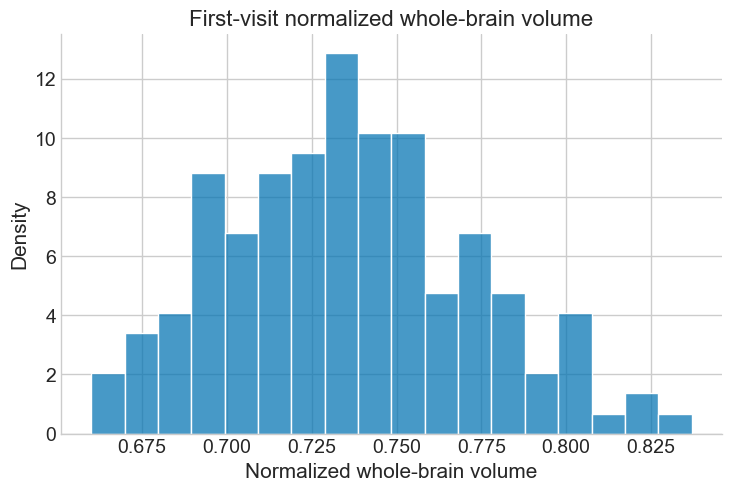

In [423]:
y_nwbv = first_visit["nWBV"].dropna().to_numpy()
mu_hat, sd_hat = stats.norm.fit(y_nwbv)
x_grid = np.linspace(y_nwbv.min() - 0.01, y_nwbv.max() + 0.01, 300)

fig, ax = plt.subplots()
sns.histplot(y_nwbv, stat="density", bins=18, color=COLORS["nwbv"], alpha=0.72, edgecolor="white", ax=ax)
ax.set(
    title="First-visit normalized whole-brain volume",
    xlabel=LABELS["nWBV"],
    ylabel="Density",
)
plt.show()

### Figure 7.1B: Normal density interpretation


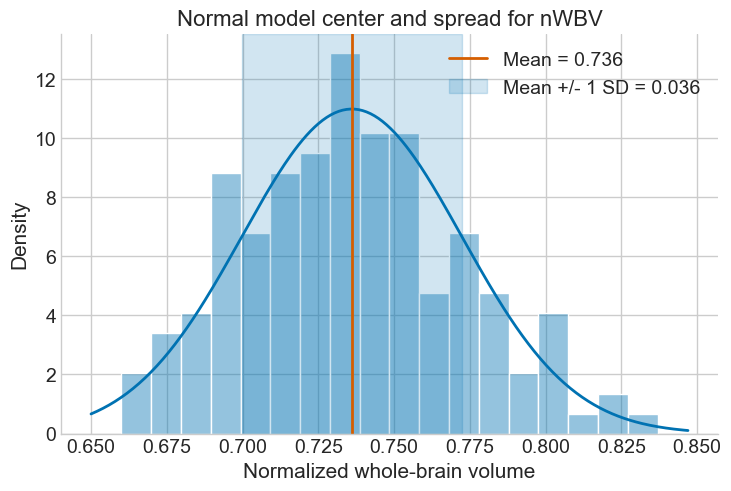

In [424]:
fig, ax = plt.subplots()
sns.histplot(y_nwbv, stat="density", bins=18, color=COLORS["nwbv"], alpha=0.42, edgecolor="white", ax=ax)
ax.plot(x_grid, stats.norm.pdf(x_grid, mu_hat, sd_hat), color=COLORS["normal"], lw=2)
ax.axvline(mu_hat, color=COLORS["reference"], lw=2, label=f"Mean = {mu_hat:.3f}")
ax.axvspan(
    mu_hat - sd_hat,
    mu_hat + sd_hat,
    color=COLORS["normal"],
    alpha=0.18,
    label=f"Mean +/- 1 SD = {sd_hat:.3f}",
)
ax.set(
    title="Normal model center and spread for nWBV",
    xlabel=LABELS["nWBV"],
    ylabel="Density",
)
ax.legend()
plt.show()

### Prior constants for the `nWBV` Normal model


In [425]:
y = first_visit["nWBV"].dropna().to_numpy()

mu_mu = 0.8
sigma_mu = 0.08
sigma_sigma = 0.1

prior_predictive_samples_nwbv = 500
posterior_draws_nwbv = 600
posterior_tune_nwbv = 600
posterior_chains_nwbv = 4
target_accept_nwbv = 0.9

### PyMC Normal model and graphical check


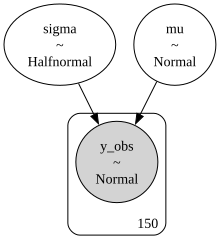

In [426]:
with pm.Model() as nwbv_normal_model:
    mu = pm.Normal("mu", mu=mu_mu, sigma=sigma_mu)
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

pm.model_to_graphviz(nwbv_normal_model)

<a id="section-72"></a>
## 7.2 Normal model workflow

With the Normal model specified, the workflow checks prior predictions, sampling diagnostics, posterior predictions, Bayesian p-values, and posterior parameter estimates.


In [427]:
with nwbv_normal_model:
    nwbv_prior = pm.sample_prior_predictive(
        samples=prior_predictive_samples_nwbv,
        random_seed=RANDOM_SEED,
    )

Sampling: [mu, sigma, y_obs]


### Figure 7.2A: Prior predictive check


Prior predictive range: [-0.386, 1.947]


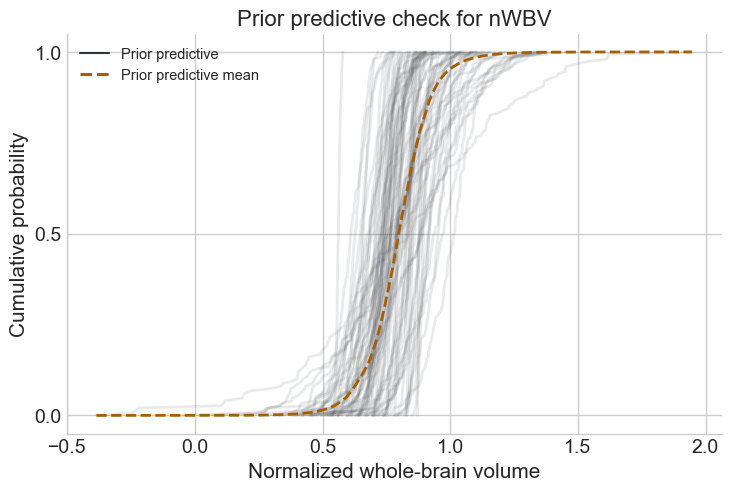

<Figure size 720x480 with 0 Axes>

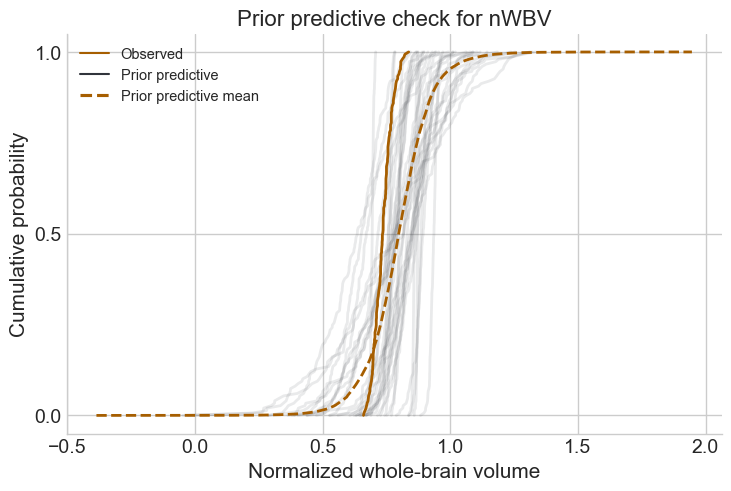

In [428]:
prior_y = np.asarray(nwbv_prior.prior_predictive["y_obs"]).reshape(-1, y.size)

print(f"Prior predictive range: [{prior_y.min():.3f}, {prior_y.max():.3f}]")

plot_alpha = 0.1
plot_linewidth = 2

az.plot_ppc(
    nwbv_prior,
    group="prior",
    kind="cumulative",
    num_pp_samples=80,
    colors=PRIOR_PPC_COLORS,
    alpha=plot_alpha,
)
plt.gca().set(
    title="Prior predictive check for nWBV",
    xlabel=LABELS["nWBV"],
    ylabel="Cumulative probability",
)
for line in plt.gca().lines:
    line.set_linewidth(plot_linewidth)
plt.show()

plt.figure()
az.plot_ppc(
    nwbv_prior,
    group="prior",
    kind="cumulative",
    observed=True,
    num_pp_samples=35,
    colors=PRIOR_PPC_COLORS,
    alpha=plot_alpha,
)
plt.gca().set(
    title="Prior predictive check for nWBV",
    xlabel=LABELS["nWBV"],
    ylabel="Cumulative probability",
)
for line in plt.gca().lines:
    line.set_linewidth(plot_linewidth)
plt.show()


### Figure 7.2B: Sampling diagnostics


In [429]:
with nwbv_normal_model:
    nwbv_idata = pm.sample(
        draws=posterior_draws_nwbv,
        tune=posterior_tune_nwbv,
        chains=posterior_chains_nwbv,
        target_accept=target_accept_nwbv,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )
    pm.sample_posterior_predictive(
        nwbv_idata,
        random_seed=RANDOM_SEED,
        progressbar=False,
        extend_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]
Sampling 4 chains for 600 tune and 600 draw iterations (2_400 + 2_400 draws total) took 29 seconds.
Sampling: [y_obs]


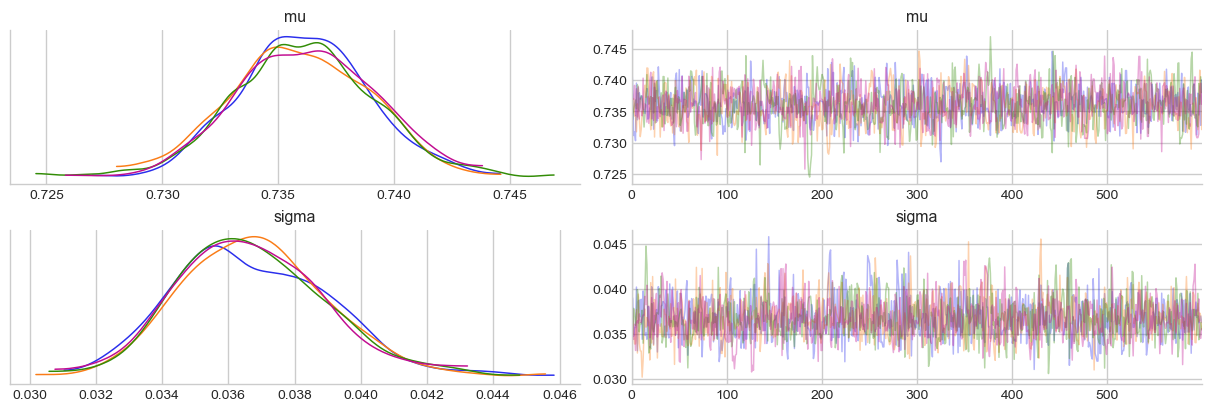

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.736,0.003,0.731,0.742,0.0,0.0,1833.0,1689.0,1.0
sigma,0.037,0.002,0.033,0.041,0.0,0.0,1972.0,1392.0,1.0


In [430]:
az.plot_trace(nwbv_idata, var_names=["mu", "sigma"], compact=False)
plt.show()

az.summary(nwbv_idata, var_names=["mu", "sigma"])

### Figure 7.2C: Posterior predictive check


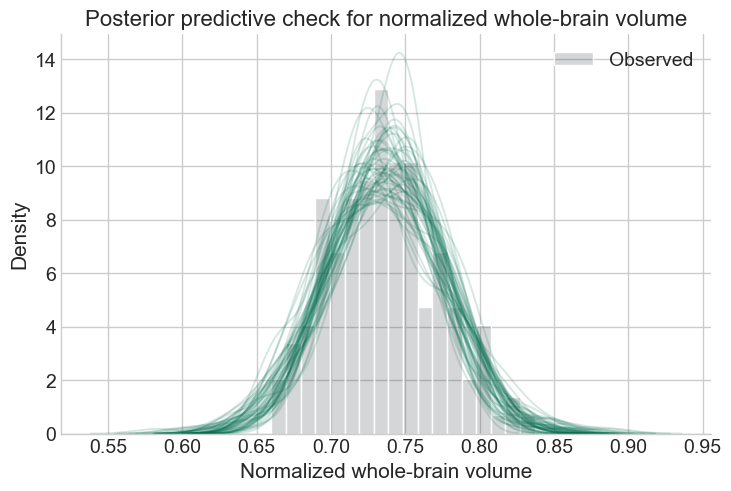

In [432]:
ppc_y = (
    az.extract(nwbv_idata, group="posterior_predictive", var_names="y_obs")
    .transpose("sample", ...)
    .to_numpy()
)
draw_idx = rng.choice(ppc_y.shape[0], size=55, replace=False)

fig, ax = plt.subplots()
sns.histplot(y, stat="density", bins=18, color=COLORS["observed"], alpha=0.2, edgecolor="white", label="Observed", ax=ax)
for idx in draw_idx:
    sns.kdeplot(ppc_y[idx], color=COLORS["posterior"], alpha=0.16, lw=1.35, ax=ax)
ax.set(
    title="Posterior predictive check for normalized whole-brain volume",
    xlabel=LABELS["nWBV"],
    ylabel="Density",
)
ax.legend()
plt.show()

<Figure size 720x480 with 0 Axes>

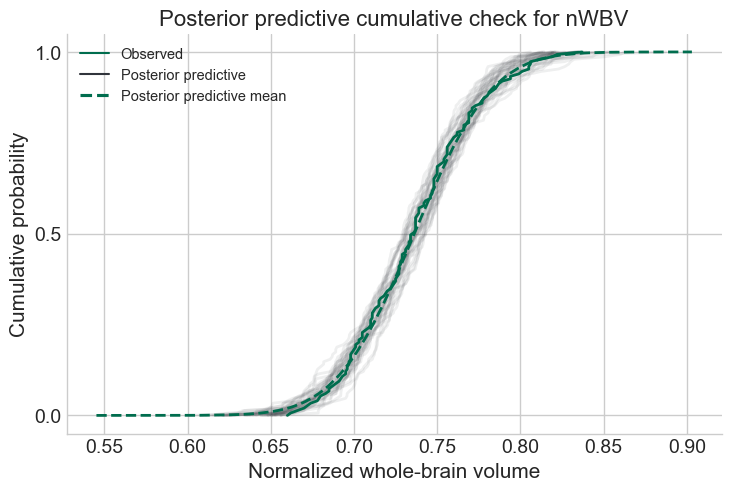

In [433]:
plot_alpha_2 = 0.08

plt.figure()
az.plot_ppc(
    nwbv_idata,
    group="posterior",
    kind="cumulative",
    observed=True,
    num_pp_samples=35,
    colors=PPC_COLORS,
    alpha=plot_alpha_2,
)
plt.gca().set(
    title="Posterior predictive cumulative check for nWBV",
    xlabel=LABELS["nWBV"],
    ylabel="Cumulative probability",
)
for line in plt.gca().lines:
    line.set_linewidth(plot_linewidth)
plt.show()


### Figure 7.2D: Prior and posterior predictive comparison


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, replicated, title, color in [
    (axes[0], prior_y, "Prior predictive", COLORS["prior"]),
    (axes[1], ppc_y, "Posterior predictive", COLORS["posterior"]),
]:
    sns.histplot(y, stat="density", bins=18, color=COLORS["observed"], alpha=0.25, edgecolor="white", label="Observed", ax=ax)
    sample_idx = rng.choice(replicated.shape[0], size=min(50, replicated.shape[0]), replace=False)
    for idx in sample_idx:
        sns.kdeplot(replicated[idx], color=color, alpha=0.08, lw=1, ax=ax)
    ax.set(title=title, xlabel=LABELS["nWBV"], ylabel="Density")
    ax.legend()

plt.tight_layout()
plt.show()


### Figure 7.2E: Bayesian p-values

Bayesian p-values compare observed summaries with the same summaries computed from posterior predictive replicated datasets. Values near 0 or 1 would signal a poor fit for that feature of the data.


Quantity,Observed,Replicated mean,94% HDI lower,94% HDI upper,Bayesian p-value
mu: sample mean,0.736100,0.736200,0.728200,0.744100,0.479600
sigma: sample SD,0.036500,0.036700,0.031200,0.042900,0.493800


C:\Users\User\AppData\Local\Temp\ipykernel_27124\1602359808.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


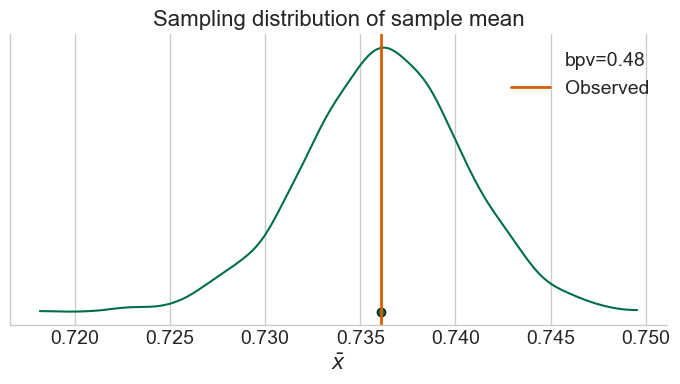

C:\Users\User\AppData\Local\Temp\ipykernel_27124\1602359808.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


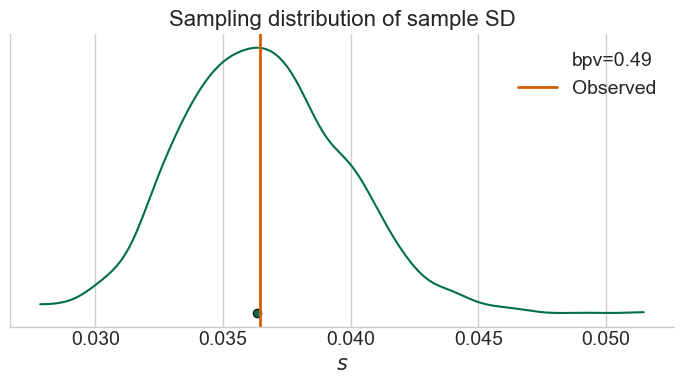

In [434]:
observed_mu_nwbv = y.mean()
observed_sigma_nwbv = y.std(ddof=1)

rep_mu_nwbv = ppc_y.mean(axis=1)
rep_sigma_nwbv = ppc_y.std(axis=1, ddof=1)

bayesian_p_mu_nwbv = np.mean(rep_mu_nwbv <= observed_mu_nwbv)
bayesian_p_sigma_nwbv = np.mean(rep_sigma_nwbv <= observed_sigma_nwbv)

mu_hdi_nwbv = az.hdi(rep_mu_nwbv, hdi_prob=0.94)
sigma_hdi_nwbv = az.hdi(rep_sigma_nwbv, hdi_prob=0.94)

bayesian_p_value_summary_nwbv = pd.DataFrame(
    {
        "Quantity": ["mu: sample mean", "sigma: sample SD"],
        "Observed": [observed_mu_nwbv, observed_sigma_nwbv],
        "Replicated mean": [rep_mu_nwbv.mean(), rep_sigma_nwbv.mean()],
        "94% HDI lower": [mu_hdi_nwbv[0], sigma_hdi_nwbv[0]],
        "94% HDI upper": [mu_hdi_nwbv[1], sigma_hdi_nwbv[1]],
        "Bayesian p-value": [bayesian_p_mu_nwbv, bayesian_p_sigma_nwbv],
    }
)

display(
    pretty_table(
        bayesian_p_value_summary_nwbv.round(4),
        "Table 7.2D: Bayesian p-values for nWBV mean and SD",
    )
)

fig, ax = plt.subplots(figsize=(7, 4))
az.plot_bpv(
    nwbv_idata,
    kind="t_stat",
    t_stat="mean",
    var_names=["y_obs"],
    color=COLORS["posterior"],
    ax=ax,
    show=False,
)
ax.axvline(observed_mu_nwbv, color=COLORS["reference"], lw=2, label="Observed")
ax.set_title("Sampling distribution of sample mean")
ax.set_xlabel("$\\bar{x}$")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
az.plot_bpv(
    nwbv_idata,
    kind="t_stat",
    t_stat="std",
    var_names=["y_obs"],
    color=COLORS["posterior"],
    ax=ax,
    show=False,
)
ax.axvline(observed_sigma_nwbv, color=COLORS["reference"], lw=2, label="Observed")
ax.set_title("Sampling distribution of sample SD")
ax.set_xlabel("$s$")
ax.legend()

plt.tight_layout()
plt.show()


### Figure 7.2F: Posterior distributions


C:\Users\User\AppData\Local\Temp\ipykernel_27124\1866643969.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


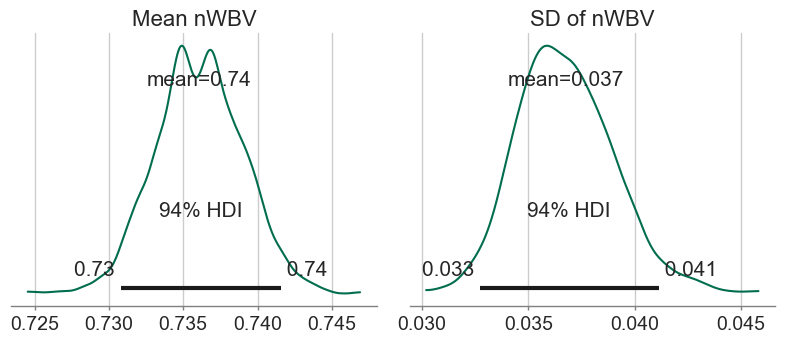

,mean,sd,hdi_3%,hdi_97%
mu,0.736,0.003,0.731,0.742
sigma,0.037,0.002,0.033,0.041


In [431]:
axes = az.plot_posterior(
    nwbv_idata,
    var_names=["mu", "sigma"],
    hdi_prob=0.94,
    figsize=(8, 3.6),
    color=COLORS["posterior"],
)
axes[0].set_title("Mean nWBV")
axes[1].set_title("SD of nWBV")
plt.tight_layout()
plt.show()
az.summary(nwbv_idata, var_names=["mu", "sigma"], hdi_prob=0.94, kind="stats")

<a id="section-73"></a>
## 7.3 Comparing across ages

The first comparison is unpaired: one first-visit `nWBV` value per subject, split into younger and older age groups.


### Figure 7.3A: First-visit `nWBV` by age group


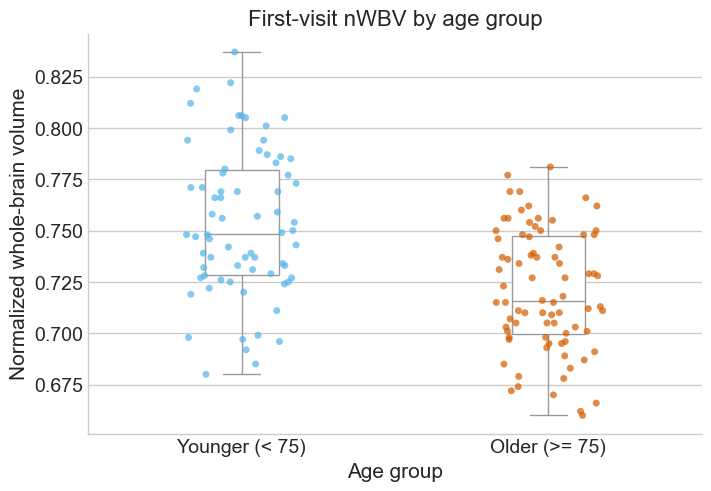

In [436]:
fig, ax = plt.subplots(figsize=(7, 4.8))

sns.boxplot(data=age_groups, x="age_group", y="nWBV", order=age_group_labels, width=0.24, color="white", fliersize=0, ax=ax)
sns.stripplot(
    data=age_groups,
    x="age_group",
    y="nWBV",
    hue="age_group",
    order=age_group_labels,
    palette=AGE_GROUP_COLORS,
    alpha=0.72,
    jitter=0.18,
    legend=False,
    ax=ax,
)
ax.set(
    title="First-visit nWBV by age group",
    xlabel="Age group",
    ylabel=LABELS["nWBV"],
)
plt.show()


### Figure 7.3B: Age-group model data table


In [ ]:
age_model_table = age_groups[["Subject.ID", "Age", "age_group", "nWBV"]].head(10).copy()
display(pretty_table(age_model_table.round(3), "Figure 7.3B: one first-visit nWBV value per subject enters the age-group model"))


### Prior constants for the age-group model


In [442]:
nwbv_age = age_groups["nWBV"].to_numpy()
age_group_idx = age_groups["age_group"].cat.codes.to_numpy()
coords_age_group = {"age_group": age_group_labels, "obs": np.arange(nwbv_age.size)}

# Reuse the single-group nWBV prior scale from Section 7.2.
mu_mu_age = mu_mu
sigma_mu_age = sigma_mu*2
sigma_sigma_age = sigma_sigma

prior_predictive_samples_age = prior_predictive_samples_nwbv
posterior_draws_age = posterior_draws_nwbv
posterior_tune_age = posterior_tune_nwbv
posterior_chains_age = posterior_chains_nwbv
target_accept_age = target_accept_nwbv


### PyMC age-group model


In [443]:
with pm.Model(coords=coords_age_group) as age_group_model:
    age_group = pm.Data("age_group", age_group_idx, dims="obs")
    mu_group = pm.Normal("mu_group", mu=mu_mu_age, sigma=sigma_mu_age, dims="age_group")
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma_age)
    mu_diff = pm.Deterministic("mu_diff", mu_group[1] - mu_group[0])
    cohen_d = pm.Deterministic("cohen_d", mu_diff / sigma)
    nwbv_obs = pm.Normal("nwbv_obs", mu=mu_group[age_group], sigma=sigma, observed=nwbv_age, dims="obs")

age_group_model



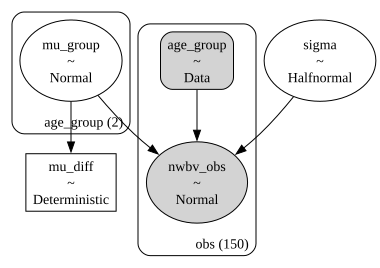

In [444]:
pm.model_to_graphviz(age_group_model, 
                     var_names=["mu_group", "sigma", "mu_diff", "age_group", "nwbv_obs"])

### Figure 7.3C: Age-group prior predictive check


Sampling: [mu_group, nwbv_obs, sigma]


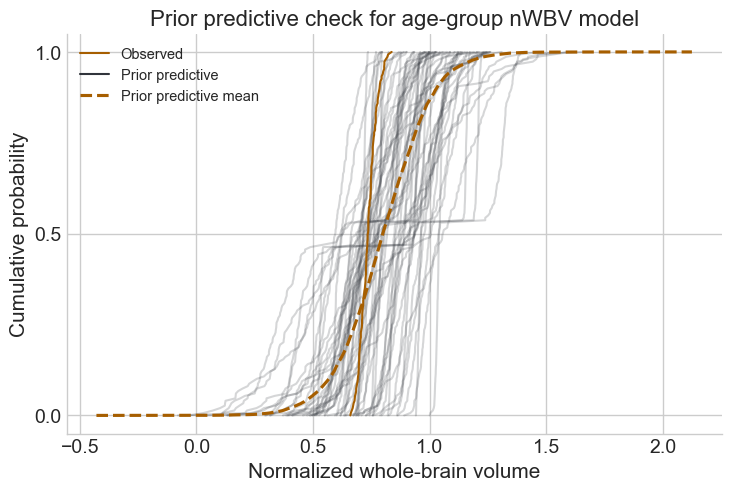

In [445]:
with age_group_model:
    age_group_prior = pm.sample_prior_predictive(samples=prior_predictive_samples_age, random_seed=RANDOM_SEED)

az.plot_ppc(
    age_group_prior,
    group="prior",
    kind="cumulative",
    observed=True,
    num_pp_samples=60,
    colors=PRIOR_PPC_COLORS,
)
plt.gca().set(
    title="Prior predictive check for age-group nWBV model",
    xlabel=LABELS["nWBV"],
    ylabel="Cumulative probability",
)
plt.show()


### Sample the age-group model


In [446]:
with age_group_model:
    age_group_idata = pm.sample(
        draws=posterior_draws_age,
        tune=posterior_tune_age,
        chains=posterior_chains_age,
        target_accept=target_accept_age,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

az.summary(age_group_idata, var_names=["mu_group", "mu_diff", "sigma"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_group, sigma]
Sampling 4 chains for 600 tune and 600 draw iterations (2_400 + 2_400 draws total) took 27 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_group[Younger (< 75)],0.754,0.004,0.746,0.761,0.0,0.0,2374.0,1500.0,1.0
mu_group[Older (>= 75)],0.721,0.004,0.714,0.728,0.0,0.0,2388.0,1776.0,1.0
mu_diff,-0.033,0.005,-0.043,-0.023,0.0,0.0,2267.0,1886.0,1.0
sigma,0.033,0.002,0.029,0.037,0.0,0.0,2480.0,1874.0,1.0


### Figure 7.3D: Age-group sampling diagnostics


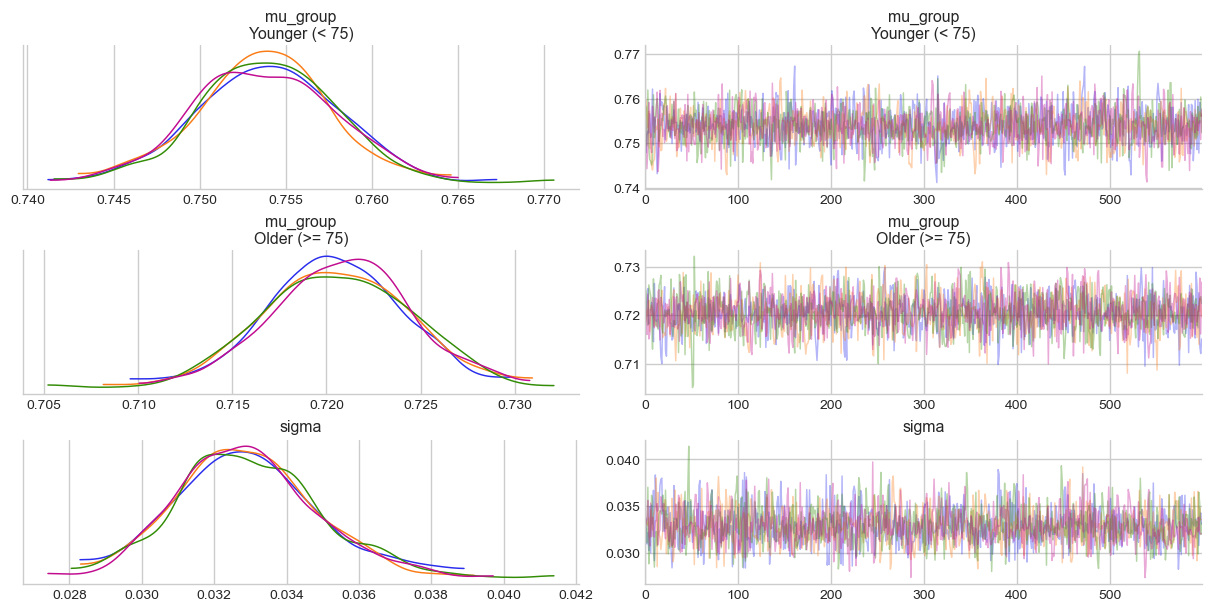

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
mu_group[Younger (< 75)],0.754,0.004,0.746,0.761,2374.0,1500.0,1.0
mu_group[Older (>= 75)],0.721,0.004,0.714,0.728,2388.0,1776.0,1.0
mu_diff,-0.033,0.005,-0.043,-0.023,2267.0,1886.0,1.0
sigma,0.033,0.002,0.029,0.037,2480.0,1874.0,1.0


In [447]:
az.plot_trace(age_group_idata, var_names=["mu_group", "sigma"], compact=False)
plt.show()

az.summary(age_group_idata, var_names=["mu_group", "mu_diff", "sigma"])[["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]]


### Figure 7.3E: Posterior predictive check by age group


C:\Users\User\AppData\Local\Temp\ipykernel_27124\769546683.py:56: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


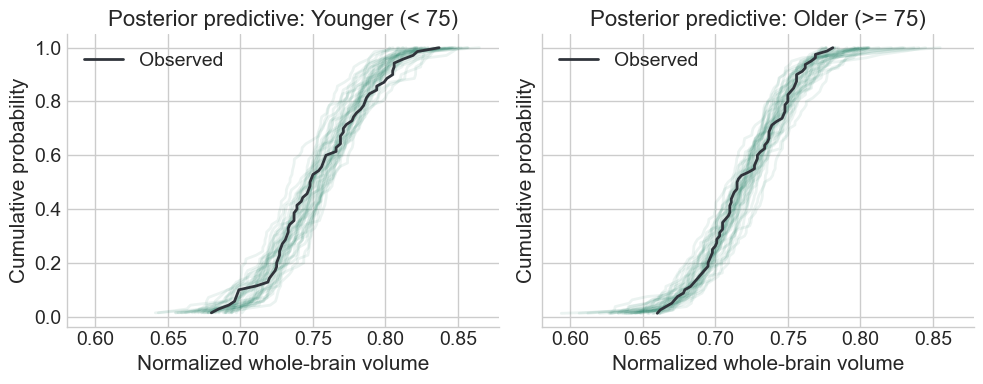

In [448]:
# Compute posterior predictive directly from posterior parameter draws.
# PyMC sample_posterior_predictive treats mu_group and sigma as variables
# to resample (from their priors) when dims/coords are used, producing
# prior-predictive-like samples rather than posterior-predictive samples.
# Drawing directly from the posterior avoids this.
mu_group_draws = age_group_idata.posterior["mu_group"].values  # (chain, draw, 2)
sigma_draws = age_group_idata.posterior["sigma"].values         # (chain, draw)
mu_flat = mu_group_draws.reshape(-1, 2)   # (n_samples, 2)
sigma_flat = sigma_draws.reshape(-1, 1)   # (n_samples, 1) - broadcasts across obs
mu_per_obs = mu_flat[:, age_group_idx]    # (n_samples, n_obs)
rng_ppc = np.random.default_rng(RANDOM_SEED)
age_group_ppc = rng_ppc.normal(mu_per_obs, sigma_flat)  # (n_samples, n_obs)


def plot_empirical_cdf(values, ax, color, alpha=1.0, linewidth=2.0, label=None):
    sorted_values = np.sort(values)
    cumulative_probability = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    ax.plot(
        sorted_values,
        cumulative_probability,
        color=color,
        alpha=alpha,
        lw=linewidth,
        label=label,
    )


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, label in zip(axes, age_group_labels):
    obs_idx = np.flatnonzero(age_groups["age_group"].to_numpy() == label)
    group_observed = nwbv_age[obs_idx]
    group_replicated = age_group_ppc[:, obs_idx]
    draw_idx = rng.choice(group_replicated.shape[0], size=min(35, group_replicated.shape[0]), replace=False)

    for draw in draw_idx:
        plot_empirical_cdf(
            group_replicated[draw],
            ax=ax,
            color=COLORS["posterior"],
            alpha=plot_alpha_2,
            linewidth=plot_linewidth,
        )
    plot_empirical_cdf(
        group_observed,
        ax=ax,
        color=COLORS["observed"],
        linewidth=plot_linewidth,
        label="Observed",
    )
    ax.set(
        title=f"Posterior predictive: {label}",
        xlabel=LABELS["nWBV"],
        ylabel="Cumulative probability",
    )
    ax.legend()
plt.tight_layout()
plt.show()


### Figure 7.3F: Posterior age-group means


C:\Users\User\AppData\Local\Temp\ipykernel_27124\1436054980.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


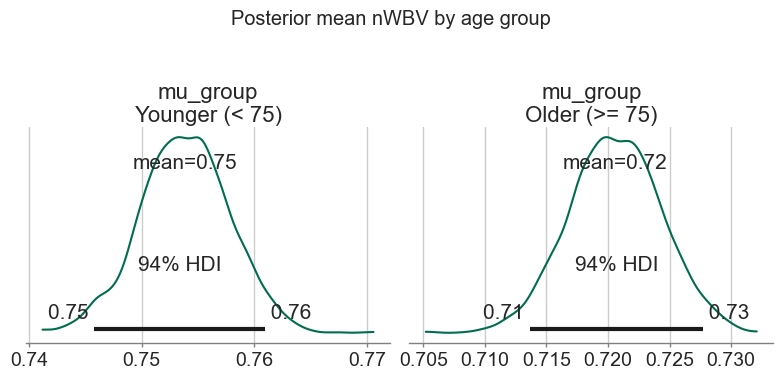

In [449]:
az.plot_posterior(
    age_group_idata,
    var_names=["mu_group"],
    coords={"age_group": age_group_labels},
    hdi_prob=0.94,
    figsize=(8, 3.6),
    color=COLORS["posterior"],
)
plt.gcf().suptitle("Posterior mean nWBV by age group", y=1.05)
plt.tight_layout()
plt.show()


### Figure 7.3G: Posterior age-group difference


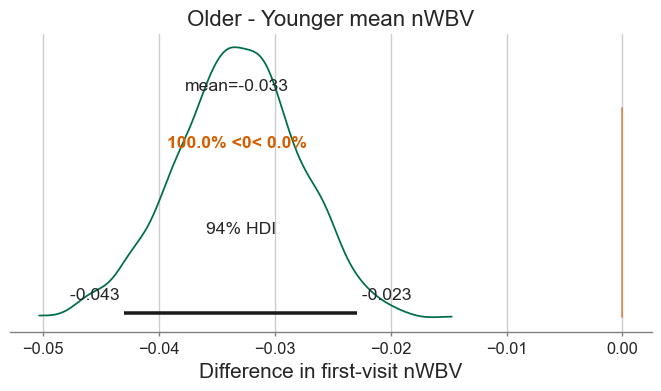

In [450]:
az.plot_posterior(
    age_group_idata,
    var_names=["mu_diff"],
    ref_val=0,
    ref_val_color=COLORS["reference"],
    hdi_prob=0.94,
    figsize=(6.5, 3.8),
    color=COLORS["posterior"],
)
plt.gca().set_title("Older - Younger mean nWBV")
plt.gca().set_xlabel("Difference in first-visit nWBV")
plt.show()


<a id="section-74"></a>
## 7.4 Effect sizes for normal models

The raw difference is in `nWBV` units. Cohen's `d` divides that difference by the shared `sigma`, giving a standardized effect size.


### Figure 7.4A: Raw age-group effect


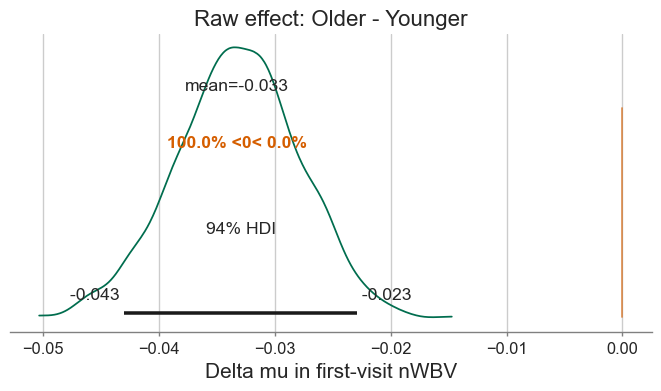

In [451]:
az.plot_posterior(
    age_group_idata,
    var_names=["mu_diff"],
    ref_val=0,
    ref_val_color=COLORS["reference"],
    hdi_prob=0.94,
    figsize=(6.5, 3.8),
    color=COLORS["posterior"],
)
plt.gca().set_title("Raw effect: Older - Younger")
plt.gca().set_xlabel("Delta mu in first-visit nWBV")
plt.show()


### Figure 7.4B: Standardized age-group effect


In [ ]:
az.plot_posterior(
    age_group_idata,
    var_names=["cohen_d"],
    ref_val=0,
    ref_val_color=COLORS["reference"],
    hdi_prob=0.94,
    figsize=(6.5, 3.8),
    color=COLORS["posterior"],
)
plt.gca().set_title("Standardized age-group effect: Cohen's d")
plt.gca().set_xlabel("Posterior Cohen's d")
plt.show()


### Figure 7.4C: HDI and ROPE for the age-group difference

The ROPE is `[-0.005, 0.005]` nWBV units: half a percentage point of normalized whole-brain volume.


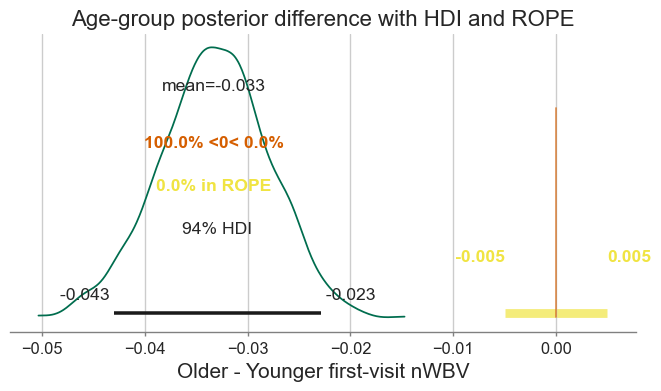

In [454]:
rope_nwbv = (-0.005, 0.005)
az.plot_posterior(
    age_group_idata,
    var_names=["mu_diff"],
    ref_val=0,
    ref_val_color=COLORS["reference"],
    rope=rope_nwbv,
    rope_color=COLORS["rope"],
    hdi_prob=0.94,
    figsize=(6.5, 3.8),
    color=COLORS["posterior"],
)
plt.gca().set_title("Age-group posterior difference with HDI and ROPE")
plt.gca().set_xlabel("Older - Younger first-visit nWBV")
plt.show()


### Figure 7.4D: Student's t distribution and t-test reference


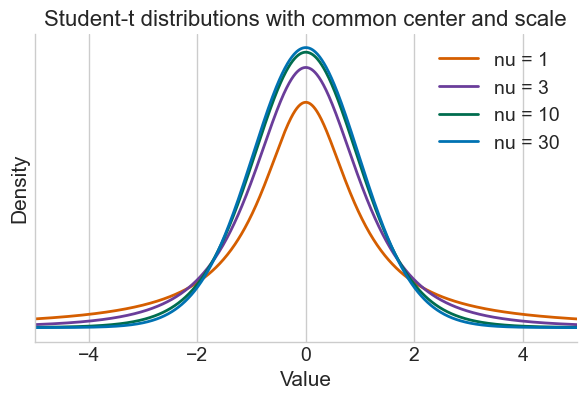

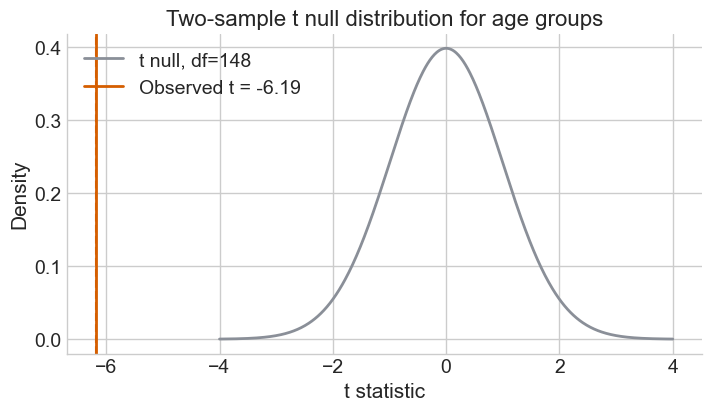

In [455]:
student_t_nu_values = [1, 3, 10, 30]
student_t_colors = [
    COLORS["reference"],
    COLORS["change"],
    COLORS["posterior"],
    COLORS["normal"],
]

fig, ax = plt.subplots(figsize=(7, 4))
for nu_value, color in zip(student_t_nu_values, student_t_colors):
    pz.StudentT(nu=nu_value, mu=0, sigma=1).plot_pdf(
        ax=ax,
        support=(-5, 5),
        baseline=False,
        color=color,
        lw=2,
    )
for line, nu_value in zip(ax.lines, student_t_nu_values):
    line.set_label(f"nu = {nu_value}")
ax.set(
    title="Student-t distributions with common center and scale",
    xlabel="Value",
    ylabel="Density",
    xlim=(-5, 5),
)
ax.legend()
plt.show()

younger_nwbv = age_groups.loc[age_groups["age_group"] == age_group_labels[0], "nWBV"].to_numpy()
older_nwbv = age_groups.loc[age_groups["age_group"] == age_group_labels[1], "nWBV"].to_numpy()
pooled_t_age = stats.ttest_ind(older_nwbv, younger_nwbv, equal_var=True)

df_age = len(older_nwbv) + len(younger_nwbv) - 2
t_obs_age = pooled_t_age.statistic
t_grid = np.linspace(-4, 4, 600)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_grid, stats.t.pdf(t_grid, df=df_age), color=COLORS["neutral"], lw=2, label=f"t null, df={df_age}")
ax.axvline(t_obs_age, color=COLORS["reference"], lw=2, label=f"Observed t = {t_obs_age:.2f}")
ax.axvline(-abs(t_obs_age), color=COLORS["reference"], lw=1.5, ls="--")
ax.set(title="Two-sample t null distribution for age groups", xlabel="t statistic", ylabel="Density")
ax.legend()
plt.show()


### Table 7.4A: Frequentist age-group test summaries


In [ ]:
# Frequentist summary table for first-visit age-group comparison

try:
    older_nwbv
except NameError:
    older_nwbv = age_groups.loc[age_groups["age_group"] == age_group_labels[1], "nWBV"].to_numpy()

n_younger = younger_nwbv.size
n_older = older_nwbv.size

mean_younger = younger_nwbv.mean()
mean_older = older_nwbv.mean()

sd_younger = younger_nwbv.std(ddof=1)
sd_older = older_nwbv.std(ddof=1)

df_age = n_younger + n_older - 2
pooled_sd = np.sqrt(
    ((n_younger - 1) * sd_younger**2 + (n_older - 1) * sd_older**2) / df_age
)

cohen_d = (mean_older - mean_younger) / pooled_sd

pooled_t_age = stats.ttest_ind(older_nwbv, younger_nwbv, equal_var=True)
t_threshold_94 = stats.t.ppf(1 - 0.06 / 2, df=df_age)

freq_summary_age = pd.DataFrame(
    {
        "Statistic": [
            "Younger mean",
            "Older mean",
            "Younger SD",
            "Older SD",
            "Pooled SD",
            "Cohen's d (Older - Younger)",
            "Degrees of freedom",
            "94% two-sided |t| threshold",
            "Two-sided p-value",
        ],
        "Value": [
            mean_younger,
            mean_older,
            sd_younger,
            sd_older,
            pooled_sd,
            cohen_d,
            df_age,
            t_threshold_94,
            pooled_t_age.pvalue,
        ],
    }
)

display(pretty_table(freq_summary_age.round(4), "Table 7.4A: Frequentist age-group test summaries"))


<a id="section-75"></a>
## 7.5 Paired comparisons

The paired comparison uses first-last change within the same subject. Pairing removes much of the between-subject variability.


### Figure 7.5A: Visits per subject


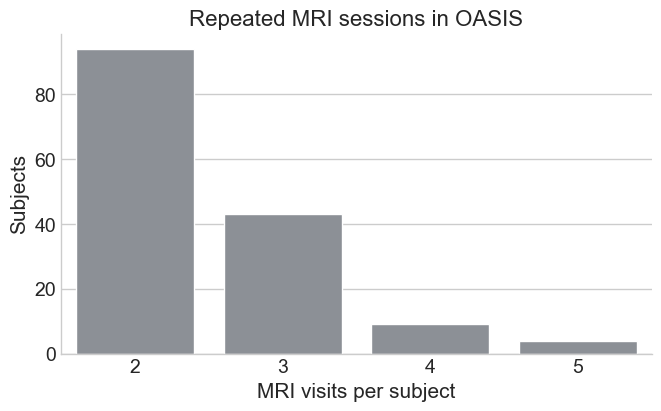

Visits,Subjects
2,94
3,43
4,9
5,4


In [437]:
visit_count_summary = (
    oasis.groupby("Subject.ID").size()
    .value_counts()
    .sort_index()
    .rename_axis("Visits")
    .reset_index(name="Subjects")
)

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(data=visit_count_summary, x="Visits", y="Subjects", color=COLORS["neutral"], ax=ax)
ax.set(
    title="Repeated MRI sessions in OASIS",
    xlabel="MRI visits per subject",
    ylabel="Subjects",
)
plt.show()

display(pretty_table(visit_count_summary, "Subjects by number of MRI visits"))


### Figure 7.5B: First and last visit ages


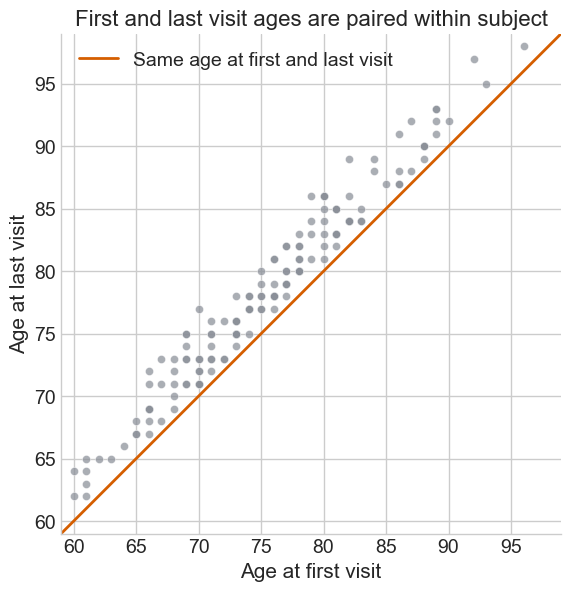

In [438]:
age_pairs = first_last.dropna(subset=["Age_first", "Age_last"]).copy()

age_axis_min = age_pairs[["Age_first", "Age_last"]].min().min() - 1
age_axis_max = age_pairs[["Age_first", "Age_last"]].max().max() + 1

fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.scatter(
    age_pairs["Age_first"],
    age_pairs["Age_last"],
    color=COLORS["neutral"],
    alpha=0.72,
    s=34,
    edgecolor="white",
    linewidth=0.4,
)
ax.plot(
    [age_axis_min, age_axis_max],
    [age_axis_min, age_axis_max],
    color=COLORS["reference"],
    lw=2,
    label="Same age at first and last visit",
)
ax.set(
    title="First and last visit ages are paired within subject",
    xlabel="Age at first visit",
    ylabel="Age at last visit",
    xlim=(age_axis_min, age_axis_max),
    ylim=(age_axis_min, age_axis_max),
)
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()


### Figure 7.5C: First and last visits are paired


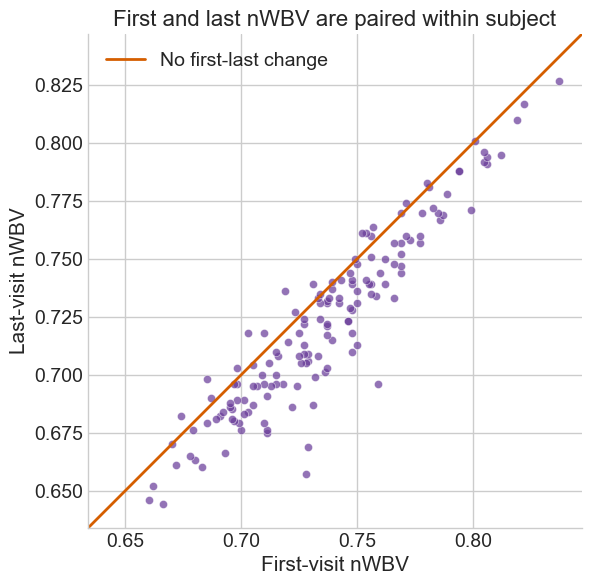

In [439]:
plot_pairs = first_last.sort_values("nWBV_change").reset_index(drop=True)

axis_min = plot_pairs[["nWBV_first", "nWBV_last"]].min().min() - 0.01
axis_max = plot_pairs[["nWBV_first", "nWBV_last"]].max().max() + 0.01

fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.scatter(
    plot_pairs["nWBV_first"],
    plot_pairs["nWBV_last"],
    color=COLORS["change"],
    alpha=0.72,
    s=34,
    edgecolor="white",
    linewidth=0.4,
)
ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    color=COLORS["reference"],
    lw=2,
    label="No first-last change",
)
ax.set(
    title="First and last nWBV are paired within subject",
    xlabel="First-visit nWBV",
    ylabel="Last-visit nWBV",
    xlim=(axis_min, axis_max),
    ylim=(axis_min, axis_max),
)
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()


### Figure 7.5D: Change-score distribution


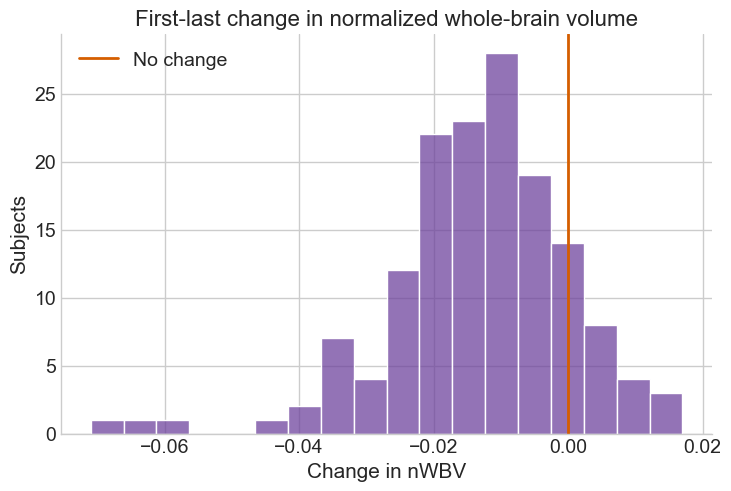

In [440]:
change_all = first_last["nWBV_change"].to_numpy()

fig, ax = plt.subplots()
sns.histplot(change_all, bins=18, color=COLORS["change"], alpha=0.72, edgecolor="white", ax=ax)
ax.axvline(0, color=COLORS["reference"], lw=2, label="No change")
ax.set(
    title="First-last change in normalized whole-brain volume",
    xlabel="Change in nWBV",
    ylabel="Subjects",
)
ax.legend()
plt.show()


### Figure 7.5E: Difference-score model


In [ ]:
difference_score_table = first_last[["Subject.ID", "Age_first", "nWBV_first", "nWBV_last", "nWBV_change"]].head(10).copy()
display(pretty_table(difference_score_table.round(4), "Figure 7.5E: first nWBV, last nWBV -> change score"))


### Prior constants for the paired Normal change model


In [458]:
change_paired = first_last["nWBV_change"].to_numpy()

# The paired model uses the same fractional nWBV units as the unpaired model.
paired_change_scale = change_paired.std(ddof=1)

mu_mu_change = mu_mu - mu_mu
sigma_mu_change = paired_change_scale * 2
sigma_sigma_change = paired_change_scale

prior_predictive_samples_change = prior_predictive_samples_age
posterior_draws_change = posterior_draws_age
posterior_tune_change = posterior_tune_age
posterior_chains_change = posterior_chains_age
target_accept_change = target_accept_age


### PyMC paired Normal change model


In [459]:
with pm.Model() as paired_normal_model:
    mu_change = pm.Normal("mu_change", mu=mu_mu_change, sigma=sigma_mu_change)
    sigma_change = pm.HalfNormal("sigma_change", sigma=sigma_sigma_change)
    change_obs = pm.Normal("change_obs", mu=mu_change, sigma=sigma_change, observed=change_paired)

paired_normal_model


### Figure 7.5F: Prior predictive check for change scores


Sampling: [change_obs, mu_change, sigma_change]


Prior predictive range: [-0.1562, 0.1608] nWBV units


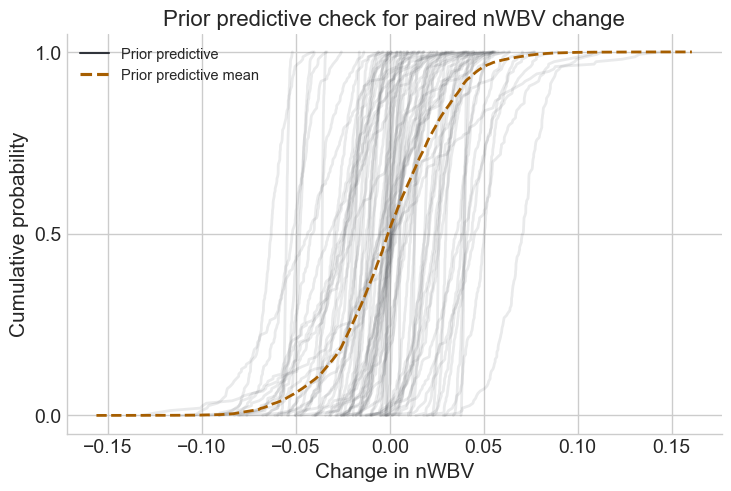

<Figure size 720x480 with 0 Axes>

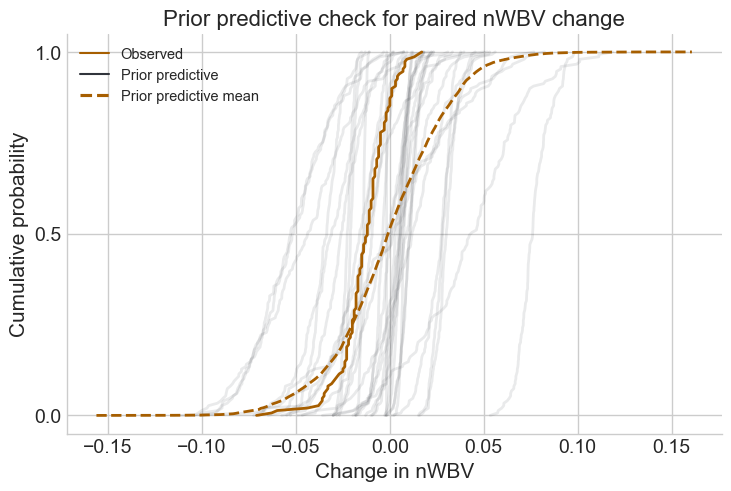

In [460]:
with paired_normal_model:
    paired_normal_prior = pm.sample_prior_predictive(samples=prior_predictive_samples_change, random_seed=RANDOM_SEED)

prior_change = np.asarray(paired_normal_prior.prior_predictive["change_obs"]).reshape(-1, change_paired.size)
print(f"Prior predictive range: [{prior_change.min():.4f}, {prior_change.max():.4f}] nWBV units")

az.plot_ppc(
    paired_normal_prior,
    group="prior",
    kind="cumulative",
    num_pp_samples=80,
    colors=PRIOR_PPC_COLORS,
    alpha=plot_alpha,
)
plt.gca().set(
    title="Prior predictive check for paired nWBV change",
    xlabel="Change in nWBV",
    ylabel="Cumulative probability",
)
for line in plt.gca().lines:
    line.set_linewidth(plot_linewidth)
plt.show()

plt.figure()
az.plot_ppc(
    paired_normal_prior,
    group="prior",
    kind="cumulative",
    observed=True,
    num_pp_samples=35,
    colors=PRIOR_PPC_COLORS,
    alpha=plot_alpha,
)
plt.gca().set(
    title="Prior predictive check for paired nWBV change",
    xlabel="Change in nWBV",
    ylabel="Cumulative probability",
)
for line in plt.gca().lines:
    line.set_linewidth(plot_linewidth)
plt.show()


### Sample the paired Normal model


In [461]:
with paired_normal_model:
    paired_normal_idata = pm.sample(
        draws=posterior_draws_change,
        tune=posterior_tune_change,
        chains=posterior_chains_change,
        target_accept=target_accept_change,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )
    pm.sample_posterior_predictive(
        paired_normal_idata,
        random_seed=RANDOM_SEED,
        progressbar=False,
        extend_inferencedata=True,
    )

az.summary(paired_normal_idata, var_names=["mu_change", "sigma_change"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_change, sigma_change]
Sampling 4 chains for 600 tune and 600 draw iterations (2_400 + 2_400 draws total) took 27 seconds.
Sampling: [change_obs]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_change,-0.013,0.001,-0.015,-0.011,0.0,0.0,1745.0,1410.0,1.0
sigma_change,0.014,0.001,0.012,0.015,0.0,0.0,2336.0,1617.0,1.0


### Figure 7.5G: Paired Normal sampling diagnostics


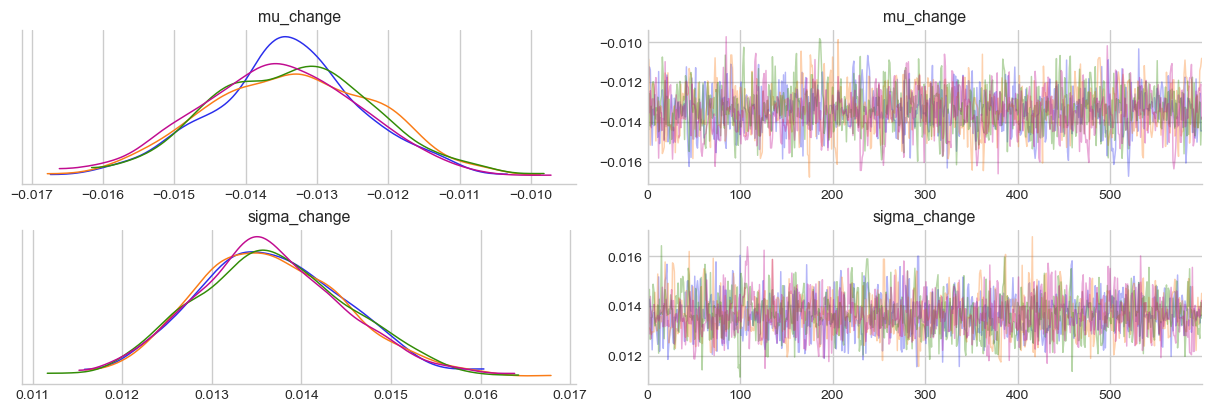

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
mu_change,-0.013,0.001,-0.015,-0.011,1745.0,1410.0,1.0
sigma_change,0.014,0.001,0.012,0.015,2336.0,1617.0,1.0


In [462]:
az.plot_trace(paired_normal_idata, var_names=["mu_change", "sigma_change"], compact=False)
plt.show()

az.summary(paired_normal_idata, var_names=["mu_change", "sigma_change"])[["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]]


### Figure 7.5H: Posterior for average change


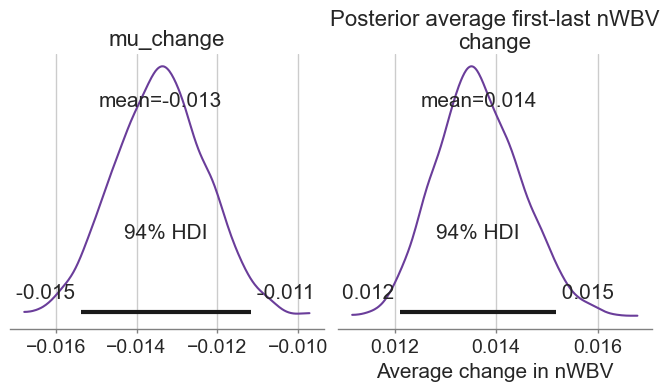

In [463]:
az.plot_posterior(
    paired_normal_idata,
    var_names=["mu_change", "sigma_change"],
    hdi_prob=0.94,
    figsize=(6.5, 3.8),
    color=COLORS["change"],
)
plt.gca().set_title("Posterior average first-last nWBV change")
plt.gca().set_xlabel("Average change in nWBV")
plt.show()


### Figure 7.5I: Paired Normal posterior predictive check


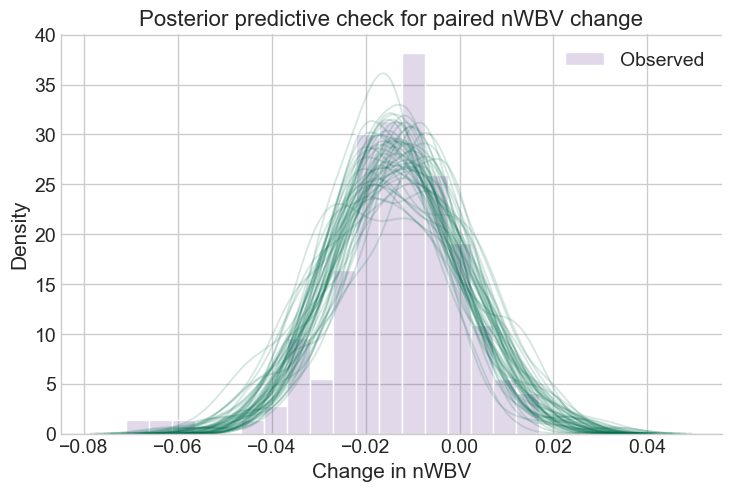

<Figure size 720x480 with 0 Axes>

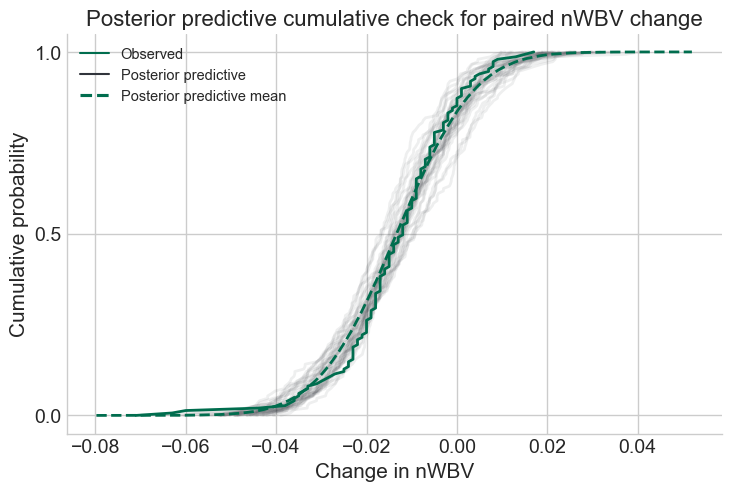

In [464]:
paired_normal_ppc = (
    az.extract(paired_normal_idata, group="posterior_predictive", var_names="change_obs")
    .transpose("sample", ...)
    .to_numpy()
)

draw_idx = rng.choice(paired_normal_ppc.shape[0], size=min(55, paired_normal_ppc.shape[0]), replace=False)

fig, ax = plt.subplots()
sns.histplot(change_paired, stat="density", bins=18, color=COLORS["change"], alpha=0.2, edgecolor="white", label="Observed", ax=ax)
for idx in draw_idx:
    sns.kdeplot(paired_normal_ppc[idx], color=COLORS["posterior"], alpha=0.16, lw=1.35, ax=ax)
ax.set(
    title="Posterior predictive check for paired nWBV change",
    xlabel="Change in nWBV",
    ylabel="Density",
)
ax.legend()
plt.show()

plt.figure()
az.plot_ppc(
    paired_normal_idata,
    group="posterior",
    kind="cumulative",
    observed=True,
    num_pp_samples=35,
    colors=PPC_COLORS,
    alpha=plot_alpha_2,
)
plt.gca().set(
    title="Posterior predictive cumulative check for paired nWBV change",
    xlabel="Change in nWBV",
    ylabel="Cumulative probability",
)
for line in plt.gca().lines:
    line.set_linewidth(plot_linewidth)
plt.show()


<a id="section-76"></a>
## 7.6 Robust models

Normal likelihoods are sensitive to tail observations. A Student-t likelihood keeps the same center-and-spread idea while allowing heavier tails.


### Figure 7.6A: Normal vs Student-t densities


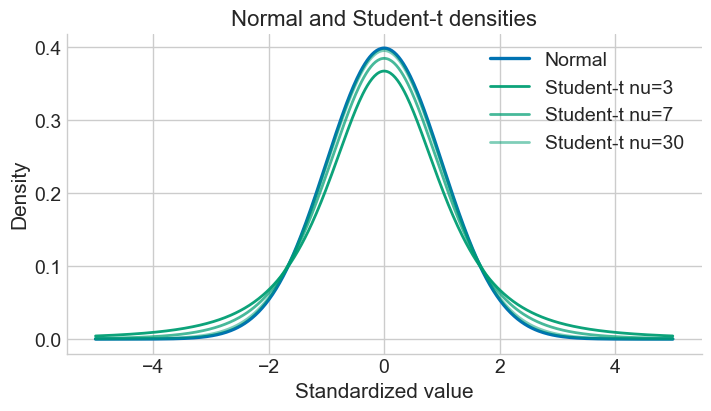

In [466]:
x_t = np.linspace(-5, 5, 500)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_t, stats.norm.pdf(x_t), color=COLORS["normal"], lw=2.4, label="Normal")
for nu_value, alpha in zip([3, 7, 30], [0.95, 0.72, 0.50]):
    ax.plot(x_t, stats.t.pdf(x_t, df=nu_value), color=COLORS["student_t"], alpha=alpha, lw=2, label=f"Student-t nu={nu_value}")
ax.set(title="Normal and Student-t densities", xlabel="Standardized value", ylabel="Density")
ax.legend()
plt.show()


### Prior constants for the Student-t change model


In [467]:
# Reuse the paired Normal change-model prior scale; only the tail parameter is new.
mu_mu_student = mu_mu_change
sigma_mu_student = sigma_mu_change
sigma_sigma_student = sigma_sigma_change
nu_min_student = 2
lam_nu_student = 1 / 10

prior_predictive_samples_student = prior_predictive_samples_change
posterior_draws_student = posterior_draws_change
posterior_tune_student = posterior_tune_change
posterior_chains_student = posterior_chains_change
target_accept_student = target_accept_change


### PyMC Student-t change model


In [469]:
with pm.Model() as paired_student_t_model:
    mu_change = pm.Normal("mu_change", mu=mu_mu_student, sigma=sigma_mu_student)
    sigma_change = pm.HalfNormal("sigma_change", sigma=sigma_sigma_student)
    nu_excess = pm.Exponential("nu_excess", lam=lam_nu_student)
    nu = pm.Deterministic("nu", nu_min_student + nu_excess)
    change_obs = pm.StudentT("change_obs", nu=nu, mu=mu_change, sigma=sigma_change, observed=change_paired)

paired_student_t_model


### Figure 7.6B: Student-t prior predictive check


Sampling: [change_obs, mu_change, nu_excess, sigma_change]


Prior predictive central 98% range: [-0.0735, 0.0758] nWBV units


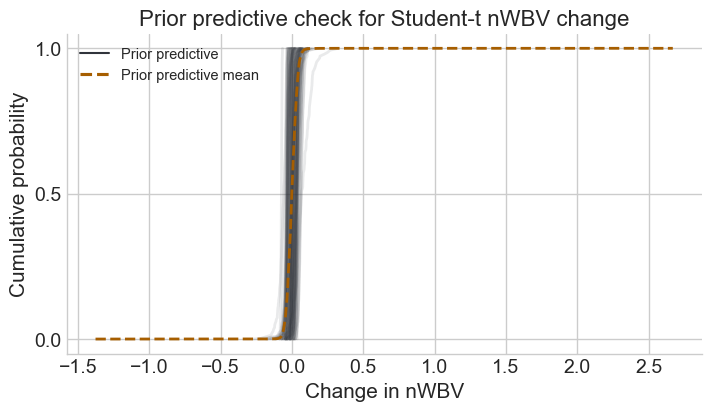

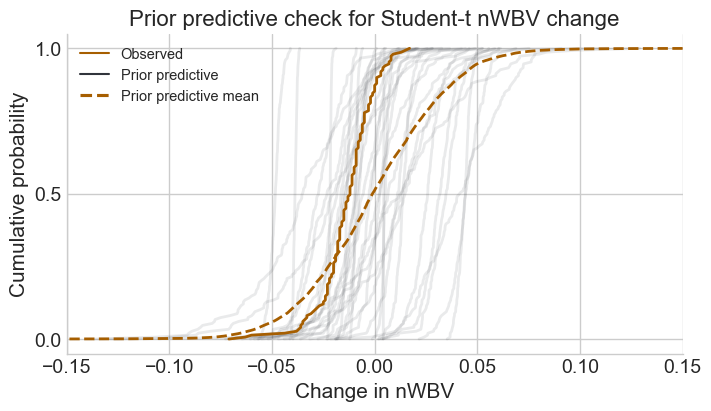

In [470]:
with paired_student_t_model:
    paired_student_t_prior = pm.sample_prior_predictive(
        samples=prior_predictive_samples_student,
        random_seed=RANDOM_SEED,
    )

prior_student_change = np.asarray(paired_student_t_prior.prior_predictive["change_obs"]).reshape(-1, change_paired.size)
print(
    "Prior predictive central 98% range: "
    f"[{np.quantile(prior_student_change, 0.01):.4f}, {np.quantile(prior_student_change, 0.99):.4f}] "
    "nWBV units"
)

fig, ax = plt.subplots(figsize=(7, 4))

az.plot_ppc(
    paired_student_t_prior,
    group="prior",
    kind="cumulative",
    num_pp_samples=80,
    colors=PRIOR_PPC_COLORS,
    alpha=plot_alpha,
    ax=ax,
)
ax.set(
    title="Prior predictive check for Student-t nWBV change",
    xlabel="Change in nWBV",
    ylabel="Cumulative probability",
)
for line in ax.lines:
    line.set_linewidth(plot_linewidth)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

az.plot_ppc(
    paired_student_t_prior,
    group="prior",
    kind="cumulative",
    observed=True,
    num_pp_samples=35,
    ax=ax,
    colors=PRIOR_PPC_COLORS,
    alpha=plot_alpha,
)
ax.set(
    title="Prior predictive check for Student-t nWBV change",
    xlabel="Change in nWBV",
    ylabel="Cumulative probability",
    xlim=(-0.15, 0.15),
)
for line in ax.lines:
    line.set_linewidth(plot_linewidth)
plt.show()


### Sample the Student-t model


In [471]:
with paired_student_t_model:
    paired_student_t_idata = pm.sample(
        draws=posterior_draws_student,
        tune=posterior_tune_student,
        chains=posterior_chains_student,
        target_accept=target_accept_student,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )
    pm.sample_posterior_predictive(
        paired_student_t_idata,
        random_seed=RANDOM_SEED,
        progressbar=False,
        extend_inferencedata=True,
    )

az.summary(paired_student_t_idata, var_names=["mu_change", "sigma_change", "nu"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_change, sigma_change, nu_excess]
Sampling 4 chains for 600 tune and 600 draw iterations (2_400 + 2_400 draws total) took 30 seconds.
Sampling: [change_obs]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_change,-0.013,0.001,-0.015,-0.011,0.0,0.000,1489.0,1392.0,1.0
sigma_change,0.011,0.001,0.009,0.013,0.0,0.000,1416.0,1424.0,1.0
nu,6.087,3.296,2.339,11.241,0.1,0.206,1206.0,1230.0,1.0


### Figure 7.6C: Posterior of `mu`, `sigma`, and `nu`


C:\Users\User\AppData\Local\Temp\ipykernel_27124\1978374231.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


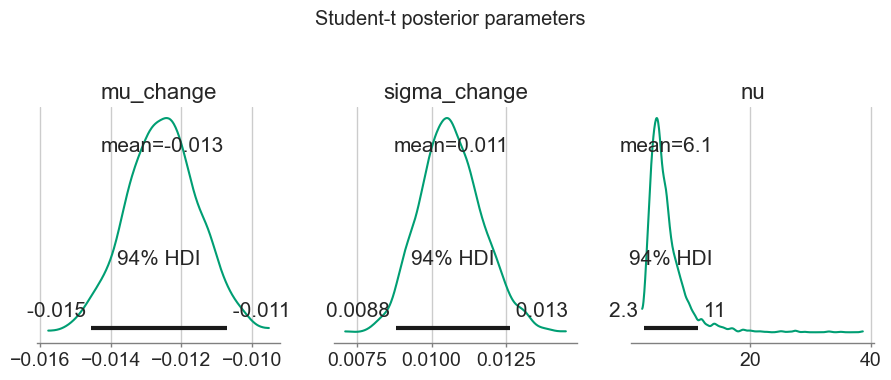

In [472]:
az.plot_posterior(
    paired_student_t_idata,
    var_names=["mu_change", "sigma_change", "nu"],
    hdi_prob=0.94,
    figsize=(9, 3.6),
    color=COLORS["student_t"],
)
plt.gcf().suptitle("Student-t posterior parameters", y=1.05)
plt.tight_layout()
plt.show()


### Figure 7.6D: Student-t posterior predictive checks and Normal comparison


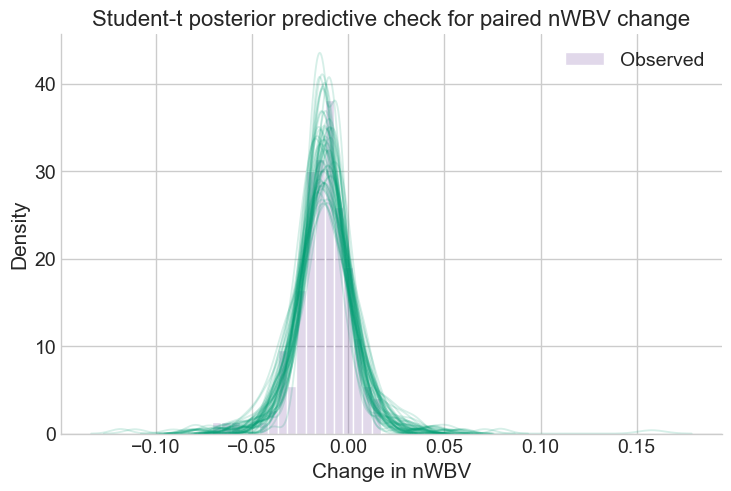

<Figure size 720x480 with 0 Axes>

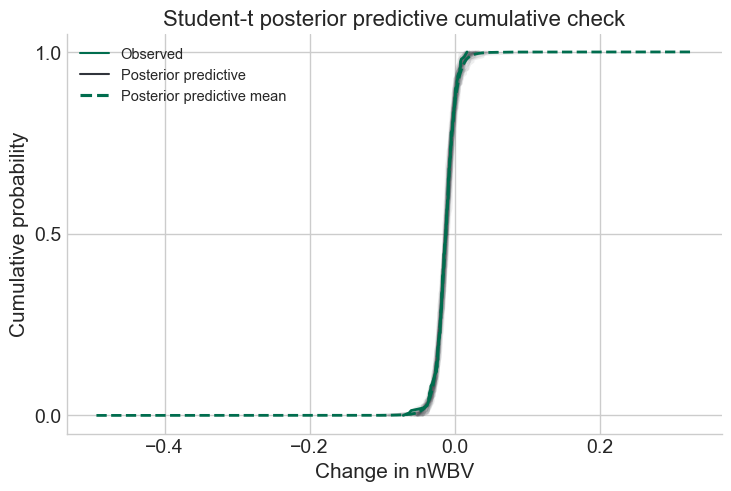

C:\Users\User\AppData\Local\Temp\ipykernel_27124\1187819139.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


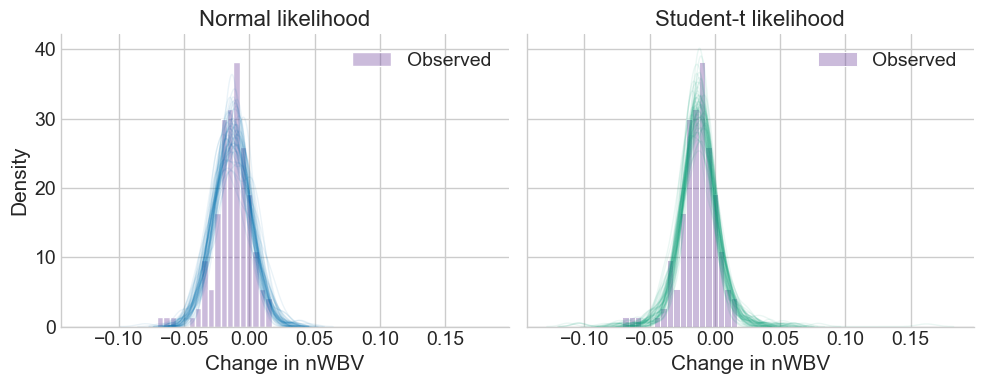

In [473]:
paired_student_t_ppc = (
    az.extract(paired_student_t_idata, group="posterior_predictive", var_names="change_obs")
    .transpose("sample", ...)
    .to_numpy()
)

draw_idx = rng.choice(paired_student_t_ppc.shape[0], size=min(55, paired_student_t_ppc.shape[0]), replace=False)

fig, ax = plt.subplots()
sns.histplot(change_paired, stat="density", bins=18, color=COLORS["change"], alpha=0.2, edgecolor="white", label="Observed", ax=ax)
for idx in draw_idx:
    sns.kdeplot(paired_student_t_ppc[idx], color=COLORS["student_t"], alpha=0.16, lw=1.35, ax=ax)
ax.set(
    title="Student-t posterior predictive check for paired nWBV change",
    xlabel="Change in nWBV",
    ylabel="Density",
)
ax.legend()
plt.show()

plt.figure()
az.plot_ppc(
    paired_student_t_idata,
    group="posterior",
    kind="cumulative",
    observed=True,
    num_pp_samples=35,
    colors=PPC_COLORS,
    alpha=plot_alpha_2,
)
plt.gca().set(
    title="Student-t posterior predictive cumulative check",
    xlabel="Change in nWBV",
    ylabel="Cumulative probability",
)
for line in plt.gca().lines:
    line.set_linewidth(plot_linewidth)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, replicated, title, model_color in [
    (axes[0], paired_normal_ppc, "Normal likelihood", COLORS["normal"]),
    (axes[1], paired_student_t_ppc, "Student-t likelihood", COLORS["student_t"]),
]:
    sns.histplot(change_paired, stat="density", bins=18, color=COLORS["change"], alpha=0.35, edgecolor="white", label="Observed", ax=ax)
    for idx in rng.choice(replicated.shape[0], size=min(60, replicated.shape[0]), replace=False):
        sns.kdeplot(replicated[idx], color=model_color, alpha=0.08, lw=1, ax=ax)
    ax.set(title=title, xlabel="Change in nWBV", ylabel="Density")
    ax.legend()
plt.tight_layout()
plt.show()


<a id="section-77"></a>
## 7.7 Effect sizes for paired comparisons

The paired effect can be reported as a raw change in `nWBV` or as a standardized change score.


### Figure 7.7A: HDI and ROPE for paired change

The paired change score uses the same ROPE: `[-0.005, 0.005]` nWBV units.


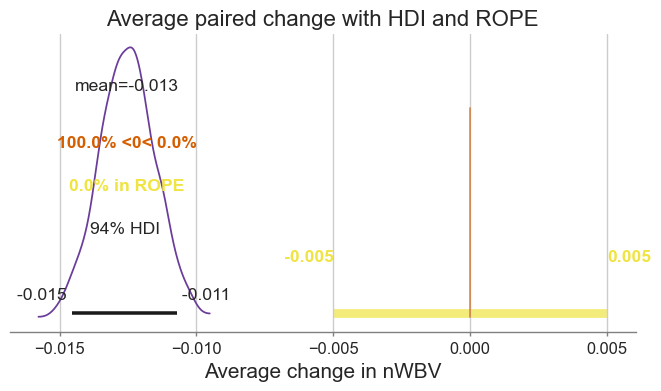

In [474]:
az.plot_posterior(
    paired_student_t_idata,
    var_names=["mu_change"],
    ref_val=0,
    ref_val_color=COLORS["reference"],
    rope=rope_nwbv,
    rope_color=COLORS["rope"],
    hdi_prob=0.94,
    figsize=(6.5, 3.8),
    color=COLORS["change"],
)
plt.gca().set_title("Average paired change with HDI and ROPE")
plt.gca().set_xlabel("Average change in nWBV")
plt.show()


### Add paired Cohen's d to the posterior


In [475]:
paired_student_t_idata.posterior["cohen_d"] = paired_student_t_idata.posterior["mu_change"] / paired_student_t_idata.posterior["sigma_change"]

### Figure 7.7B: Standardized paired effect


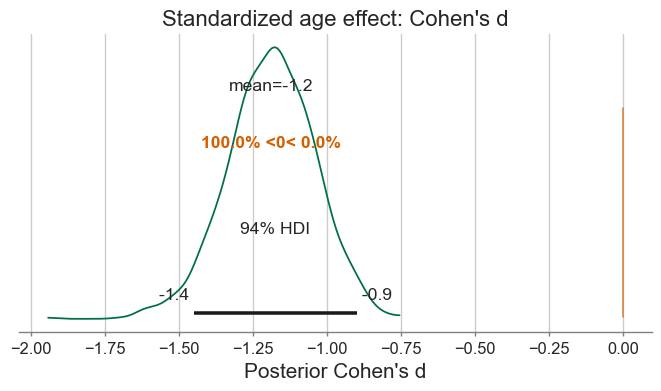

In [476]:
az.plot_posterior(
    paired_student_t_idata,
    var_names=["cohen_d"],
    ref_val=0,
    ref_val_color=COLORS["reference"],
    hdi_prob=0.94,
    figsize=(6.5, 3.8),
    color=COLORS["posterior"],
)
plt.gca().set_title("Standardized age effect: Cohen's d")
plt.gca().set_xlabel("Posterior Cohen's d")
plt.show()


### Figure 7.7C: Raw and standardized effects across analyses


In [ ]:
age_raw_effect = az.extract(age_group_idata, var_names="mu_diff").to_numpy().ravel()
paired_raw_effect = az.extract(paired_student_t_idata, var_names="mu_change").to_numpy().ravel()
age_standardized_effect = az.extract(age_group_idata, var_names="cohen_d").to_numpy().ravel()
paired_standardized_effect = az.extract(paired_student_t_idata, var_names="cohen_d").to_numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, labels, title, xlabel in [
    (
        axes[0],
        [age_raw_effect, paired_raw_effect],
        ["Unpaired age groups", "Paired first-last"],
        "Raw effects",
        "nWBV units",
    ),
    (
        axes[1],
        [age_standardized_effect, paired_standardized_effect],
        ["Unpaired age groups", "Paired first-last"],
        "Standardized effects",
        "Cohen's d",
    ),
]:
    for value_draws, label, color in zip(values, labels, [COLORS["posterior"], COLORS["change"]]):
        sns.kdeplot(value_draws, ax=ax, color=color, lw=2, label=label)
    ax.axvline(0, color=COLORS["reference"], lw=1.5)
    ax.set(title=title, xlabel=xlabel, ylabel="Density")
    ax.legend()

plt.tight_layout()
plt.show()


### Table 7.7A: Paired t and Wilcoxon signed-rank comparison


In [ ]:
paired_change_for_tests = first_last["nWBV_change"].to_numpy()
n_paired = paired_change_for_tests.size
mean_change = paired_change_for_tests.mean()
sd_change = paired_change_for_tests.std(ddof=1)
cohen_dz = mean_change / sd_change

paired_t_for_table = stats.ttest_1samp(paired_change_for_tests, popmean=0)
df_paired = n_paired - 1
t_threshold_paired = stats.t.ppf(1 - 0.06 / 2, df=df_paired)

wilcoxon_for_table = stats.wilcoxon(paired_change_for_tests, zero_method="wilcox", alternative="two-sided")
n_nonzero_change = np.count_nonzero(paired_change_for_tests)
wilcoxon_expected = n_nonzero_change * (n_nonzero_change + 1) / 4
wilcoxon_sd = np.sqrt(n_nonzero_change * (n_nonzero_change + 1) * (2 * n_nonzero_change + 1) / 24)
wilcoxon_lower_threshold = wilcoxon_expected - stats.norm.ppf(1 - 0.06 / 2) * wilcoxon_sd

paired_t_test = pd.DataFrame(
    {
        "Quantity": [
            "Sample mean of paired difference",
            "Sample SD of paired difference",
            "Cohen's dz",
            "Degrees of freedom",
            "94% two-sided |t| threshold",
            "Two-sided p-value",
        ],
        "Value": [
            mean_change,
            sd_change,
            cohen_dz,
            df_paired,
            t_threshold_paired,
            paired_t_for_table.pvalue,
        ],
    }
)

wilcoxon_test = pd.DataFrame(
    {
        "Quantity": [
            "W statistic",
            "94% two-sided W lower threshold",
            "Two-sided p-value",
        ],
        "Value": [
            wilcoxon_for_table.statistic,
            wilcoxon_lower_threshold,
            wilcoxon_for_table.pvalue,
        ],
    }
)


display(pretty_table(paired_t_test.round(4), "Table 7.7A: Paired nWBV t test"))
display(pretty_table(wilcoxon_test.round(4), "Table 7.7B: Wilcoxon signed-rank test"))


<a id="section-78"></a>
## 7.8 Next week: linear models

So far we have modeled one outcome, sometimes with a grouping variable. Linear models add predictors directly to the mean structure, letting us ask how variables relate to each other.
